# **INPUT AUDIO**

## **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Set Path File**

In [ ]:
path_dir = "/content/drive/Shared drives/PROYEK PSD KEL 10/"

path_asli1 = path_dir + "suara_asli.wav"
path_asli2 = path_dir + "suara_asli2.wav"
path_noisy_raw = path_dir + "suara_noisy.wav"

## **Install Noisereduce**

In [ ]:
!pip install noisereduce

## **Import Library**

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
import noisereduce as nr
from scipy.signal import wiener

## **Load Audio Asli 1**

In [ ]:
audio_asli1_full, sr1 = librosa.load(path_asli1, sr=None)

print("SR1:", sr1)
print("Durasi Asli 1 awal:", len(audio_asli1_full)/sr1, "detik")

durasi_detik = 46
n1 = int(sr1 * durasi_detik)
audio_asli1 = audio_asli1_full[:n1]

print("Durasi Audio Asli 1 (46 detik):", len(audio_asli1)/sr1, "detik")
Audio(audio_asli1, rate=sr1)

## **Load Audio Asli 2**

In [ ]:
audio_asli2_full, sr2 = librosa.load(path_asli2, sr=None)

print("SR2:", sr2)
print("Durasi Asli 2 awal:", len(audio_asli2_full)/sr2, "detik")

n2 = int(sr2 * durasi_detik)
audio_asli2 = audio_asli2_full[:n2]

print("Durasi Audio Asli 2 (46 detik):", len(audio_asli2)/sr2, "detik")
Audio(audio_asli2, rate=sr2)

## **Load Noise**

In [ ]:
noise_full, sr_noise = librosa.load(path_noisy_raw, sr=None)

print("SR Noise:", sr_noise)
print("Durasi Noise Asli:", len(noise_full)/sr_noise, "detik")

noise_mono = librosa.to_mono(noise_full)

durasi_detik = 46
noise_fixed = noise_mono[:sr_noise * durasi_detik]

print("Durasi Noise Setelah Dipotong:", len(noise_fixed)/sr_noise, "detik")

Audio(noise_fixed, rate=sr_noise)


# **PREPROCESSING**

## **Convert ke Mono**

In [ ]:
audio_asli1 = librosa.to_mono(audio_asli1)
audio_asli2 = librosa.to_mono(audio_asli2)
noise_fixed = librosa.to_mono(noise_fixed)

print("Convert mono selesai.")

Convert mono selesai.


## **Samakan Sample Rate**

In [ ]:
sr_common = min(sr1, sr2, sr_noise)

audio_asli1 = librosa.resample(audio_asli1, orig_sr=sr1, target_sr=sr_common)
audio_asli2 = librosa.resample(audio_asli2, orig_sr=sr2, target_sr=sr_common)
noise_fixed = librosa.resample(noise_fixed, orig_sr=sr_noise, target_sr=sr_common)

print("SR final:", sr_common)

SR final: 44100


## **Match Length**

**Match Lenght untuk Mixing Noise**

In [ ]:
def match_length_noise(noise, target):
    if len(noise) >= len(target):
        return noise[:len(target)]
    else:
        repeat = int(np.ceil(len(target) / len(noise)))
        return np.tile(noise, repeat)[:len(target)]

**Match Lenght untuk Evaluasi**

In [ ]:
def match_length(a, b):
    if len(a) < len(b):
        out = np.zeros(len(b))
        out[:len(a)] = a
        return out
    else:
        return a[:len(b)]

# **MIXING NOISE**

## **Audio Asli 1 + Noise**

In [ ]:
noise_norm = noise_fixed / np.max(np.abs(noise_fixed))
noise_level = 0.3

audio_noisy1 = audio_asli1 + noise_level * noise_norm

def normalize(x):
    mx = np.max(np.abs(x))
    return x / mx if mx > 1 else x

audio_noisy1 = normalize(audio_noisy1)

sf.write(path_dir + "audio_noisy1.wav", audio_noisy1, sr_common)

display(Audio(audio_noisy1, rate=sr_common))

## **Audio Asli 2 + Noise**

In [ ]:
noise_norm = noise_fixed / np.max(np.abs(noise_fixed))
noise_level = 0.3

audio_noisy2 = audio_asli2 + noise_level * noise_norm

def normalize(x):
    mx = np.max(np.abs(x))
    return x / mx if mx > 1 else x

audio_noisy2 = normalize(audio_noisy2)

sf.write(path_dir + "audio_noisy2.wav", audio_noisy2, sr_common)

display(Audio(audio_noisy2, rate=sr_common))

# **VISUALISASI AWAL**

# **Waveform**

In [ ]:
def plot_wave(y, sr, title):
    plt.figure(figsize=(12,4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## **Waveform Audio Asli 1**

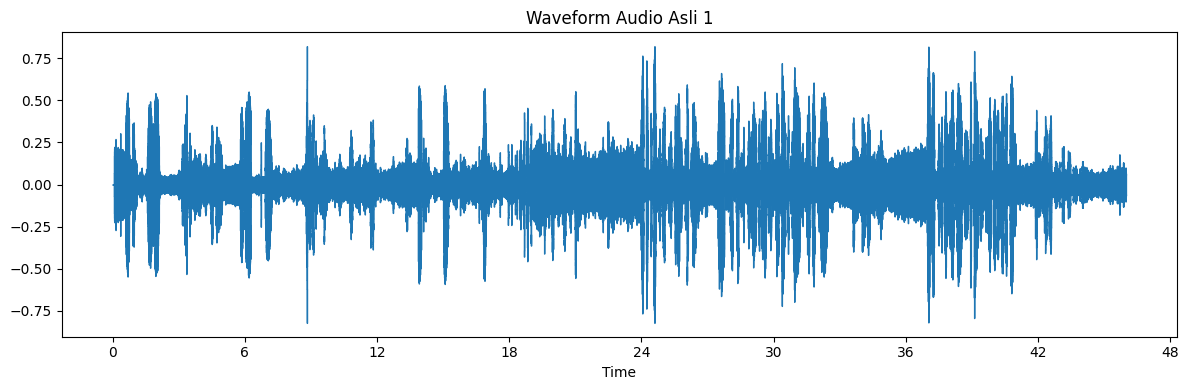

In [ ]:
plot_wave(audio_asli1, sr_common, "Waveform Audio Asli 1")

## **Waveform Audio Asli 2**

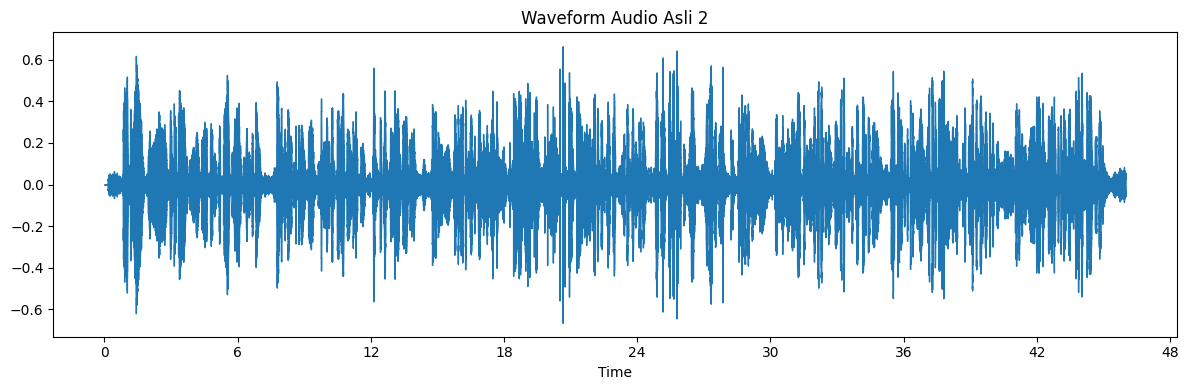

In [ ]:
plot_wave(audio_asli2, sr_common, "Waveform Audio Asli 2")

## **Waveform Noise**

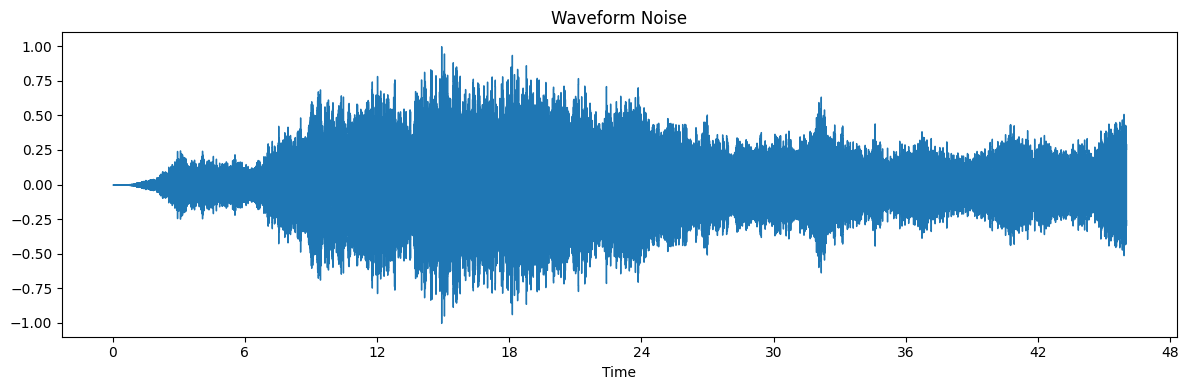

In [ ]:
plot_wave(noise_norm, sr_common, "Waveform Noise")

## **Waveform Audio Noisy 1**

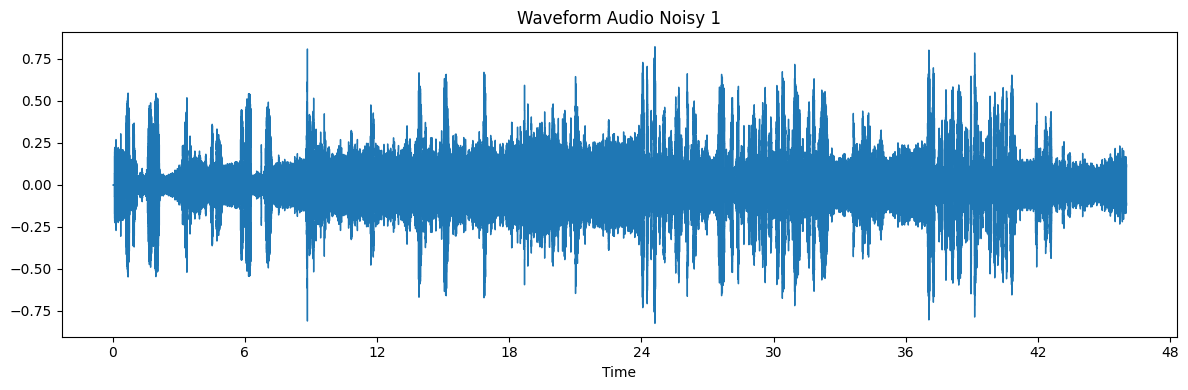

In [ ]:
plot_wave(audio_noisy1, sr_common, "Waveform Audio Noisy 1")

## **Waveform Audio Noisy 2**

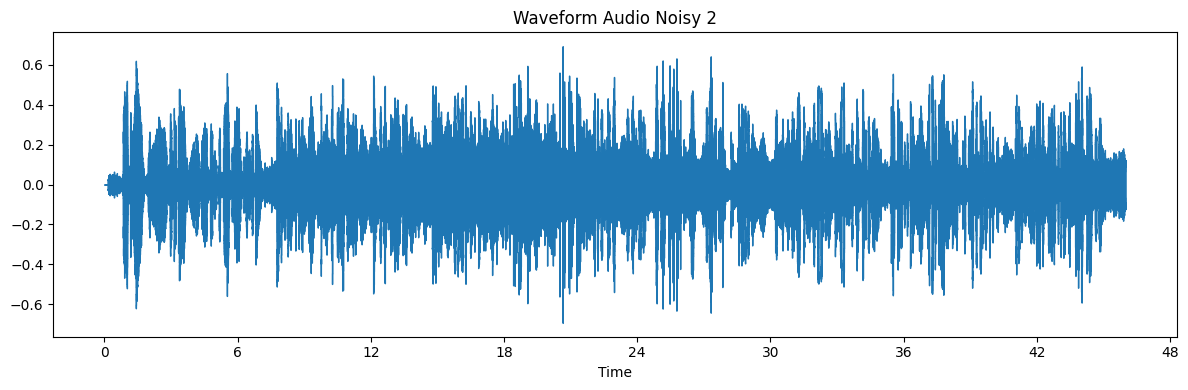

In [ ]:
plot_wave(audio_noisy2, sr_common, "Waveform Audio Noisy 2")

# **Spectrogram**

In [ ]:
def plot_spec(y, sr, title):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    plt.figure(figsize=(12,4))
    librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

## **Spectrogram Audio Asli 1**

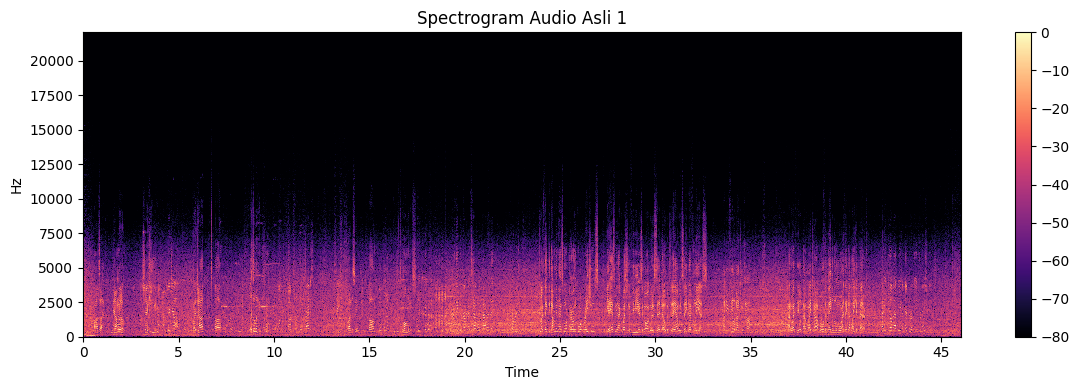

In [ ]:
plot_spec(audio_asli1, sr_common, "Spectrogram Audio Asli 1")

## **Spectrogram Audio Asli 2**

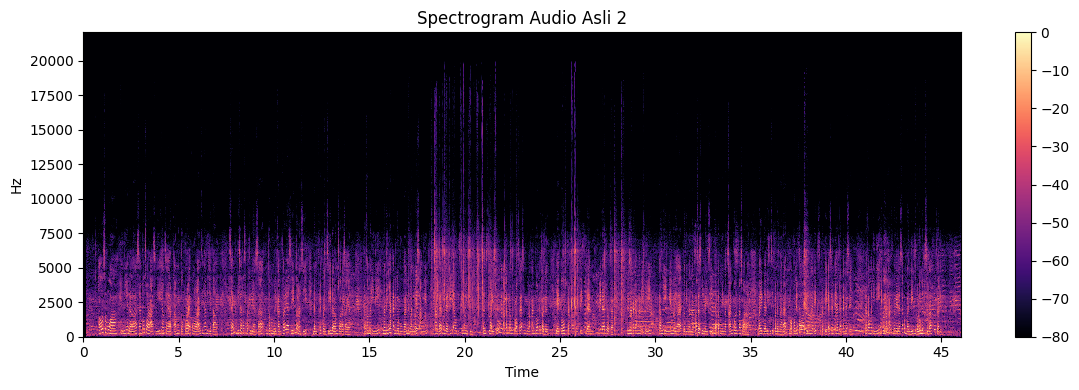

In [ ]:
plot_spec(audio_asli2, sr_common, "Spectrogram Audio Asli 2")

## **Spectrogram Noise**

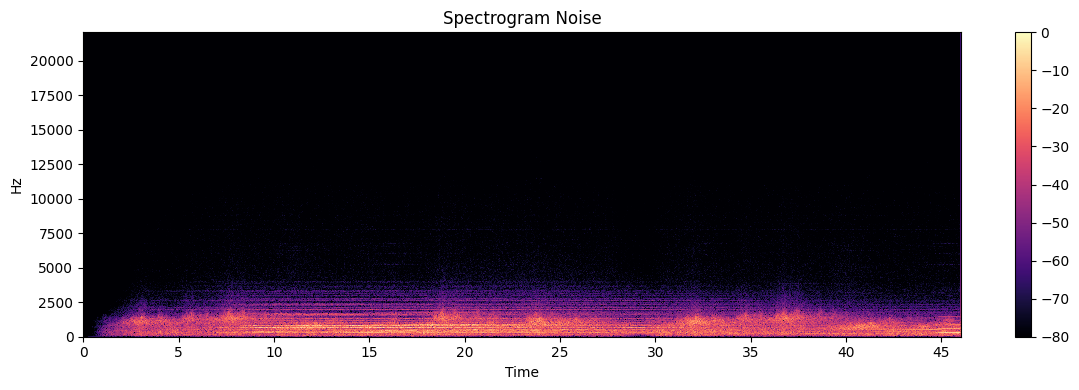

In [ ]:
plot_spec(noise_norm, sr_common, "Spectrogram Noise")

## **Spectrogram Audio Noisy 1**

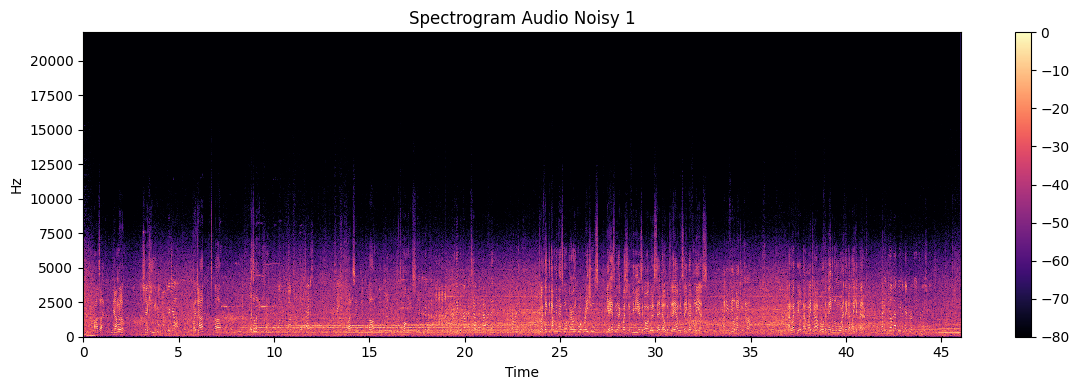

In [ ]:
plot_spec(audio_noisy1, sr_common, "Spectrogram Audio Noisy 1")

## **Spectrogram Audio Noisy 2**

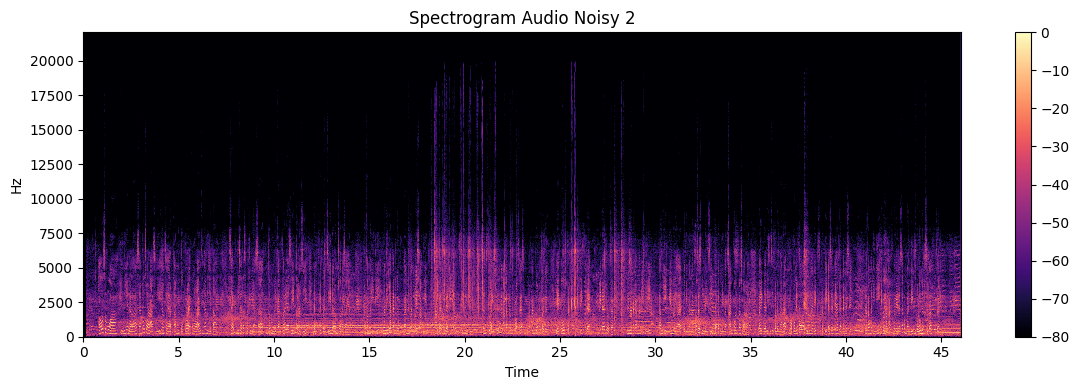

In [ ]:
plot_spec(audio_noisy2, sr_common, "Spectrogram Audio Noisy 2")

# **DENOISING**

# **Spectral Gating**

## **Spectral Gating Audio Noisy 1**

In [ ]:
audio_sg1 = nr.reduce_noise(y=audio_noisy1, sr=sr_common)

print("Spectral Gating Audio 1 selesai.")
sf.write(path_dir + "audio_sg1.wav", audio_sg1, sr_common)

Audio(audio_sg1, rate=sr_common)

## **Spectral Gating Audio Noisy 2**

In [ ]:
audio_sg2 = nr.reduce_noise(y=audio_noisy2, sr=sr_common)

print("Spectral Gating Audio 2 selesai.")
sf.write(path_dir + "audio_sg2.wav", audio_sg2, sr_common)

Audio(audio_sg2, rate=sr_common)

# **WIENER FILTER**

## **Wiener Filter Audio Noisy 1**

In [ ]:
audio_wf1 = wiener(audio_noisy1)

print("Wiener Filter Audio 1 selesai.")
sf.write(path_dir + "audio_wiener1.wav", audio_wf1, sr_common)

Audio(audio_wf1, rate=sr_common)

## **Wiener Filter Audio Noisy 2**

In [ ]:
audio_wf2 = wiener(audio_noisy2)

print("Wiener Filter Audio 2 selesai.")
sf.write(path_dir + "audio_wiener2.wav", audio_wf2, sr_common)

Audio(audio_wf2, rate=sr_common)

# **OPTIMALISASI PARAMETER DENOISING**

## **Optimalisasi Spectral Gating Audio Noisy 1**

**Parameter & Helper**

In [ ]:
props = [0.6, 0.7, 0.8]
smooths = [20, 40]

def sg_denoise(x, prop, smooth):
    return nr.reduce_noise(
        y=x, sr=sr_common,
        prop_decrease=prop,
        time_mask_smooth_ms=smooth
    )

In [ ]:
def snr(orig, den):
    noise = orig - den
    return 10 * np.log10(np.sum(orig**2) / np.sum(noise**2))

def mse(orig, den):
    return np.mean((orig - den)**2)

**Optimalisasi**

In [ ]:
best_sg1 = None
best_snr = -999

for p in props:
    for s in smooths:
        den = sg_denoise(audio_noisy1, p, s)
        score = snr(audio_asli1, match_length(den, audio_asli1))
        if score > best_snr:
            best_snr = score
            best_sg1 = den

audio_sg1_final = best_sg1
print("Optimalisasi SG1 selesai.")

Optimalisasi SG1 selesai.


## **Optimalisasi Spectral Gating Audio Noisy 2**

In [ ]:
best_sg2 = None
best_snr = -999

for p in props:
    for s in smooths:
        den = sg_denoise(audio_noisy2, p, s)
        score = snr(audio_asli2, match_length(den, audio_asli2))
        if score > best_snr:
            best_snr = score
            best_sg2 = den

audio_sg2_final = best_sg2
print("Optimalisasi SG2 selesai.")

Optimalisasi SG2 selesai.


## **Optimalisasi Wiener Filter Audio Noisy 1**

In [ ]:
kernel_sizes = [3, 5, 7, 9]

def wf_denoise(x, k):
    return wiener(x, mysize=k)

best_wf1 = None
best_snr = -999

for k in kernel_sizes:
    den = wf_denoise(audio_noisy1, k)
    score = snr(audio_asli1, match_length(den, audio_asli1))
    if score > best_snr:
        best_snr = score
        best_wf1 = den

audio_wf1_final = best_wf1
print("Optimalisasi WF1 selesai.")

Optimalisasi WF1 selesai.


## **Optimalisasi Wiener Filter Audio Noisy 2**

In [ ]:
best_wf2 = None
best_snr = -999

for k in kernel_sizes:
    den = wf_denoise(audio_noisy2, k)
    score = snr(audio_asli2, match_length(den, audio_asli2))
    if score > best_snr:
        best_snr = score
        best_wf2 = den

audio_wf2_final = best_wf2
print("Optimalisasi WF2 selesai.")

Optimalisasi WF2 selesai.


# **VISUALISASI HASIL**

# **Wafevorm**

In [ ]:
def plot_wave(y, sr, title):
    plt.figure(figsize=(12,2.8))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## **Waveform — Spectral Gating Audio Noisy 1**

In [ ]:
plot_wave(audio_sg1, sr_common, "Waveform — Spectral Gating (SG1)")

print("Play SG1:")
display(Audio(audio_sg1, rate=sr_common))

## **Waveform — Spectral Gating Audio Noisy 2**

In [ ]:
plot_wave(audio_sg2, sr_common, "Waveform — Spectral Gating (SG2)")

print("Play SG2:")
display(Audio(audio_sg2, rate=sr_common))

## **Waveform — Wiener Filter Audio Noisy 1**

In [ ]:
plot_wave(audio_wf1, sr_common, "Waveform — Wiener Filter (WF1)")

print("Play WF1:")
display(Audio(audio_wf1, rate=sr_common))

## **Waveform — Wiener Filter Audio Noisy 2**

In [ ]:
plot_wave(audio_wf2, sr_common, "Waveform — Wiener Filter (WF2)")

print("Play WF2:")
display(Audio(audio_wf2, rate=sr_common))

# **Spectrogram**

In [ ]:
def plot_spec(y, sr, title):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    plt.figure(figsize=(12,3.5))
    librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## **Spectrogram — Spectral Gating Audio Noisy 1**

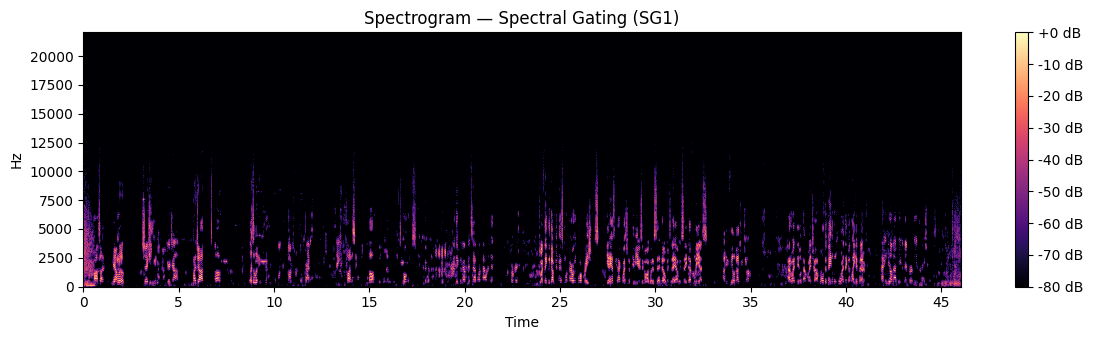

In [ ]:
plot_spec(audio_sg1, sr_common, "Spectrogram — Spectral Gating (SG1)")

## **Spectrogram — Spectral Gating Audio Noisy 2**

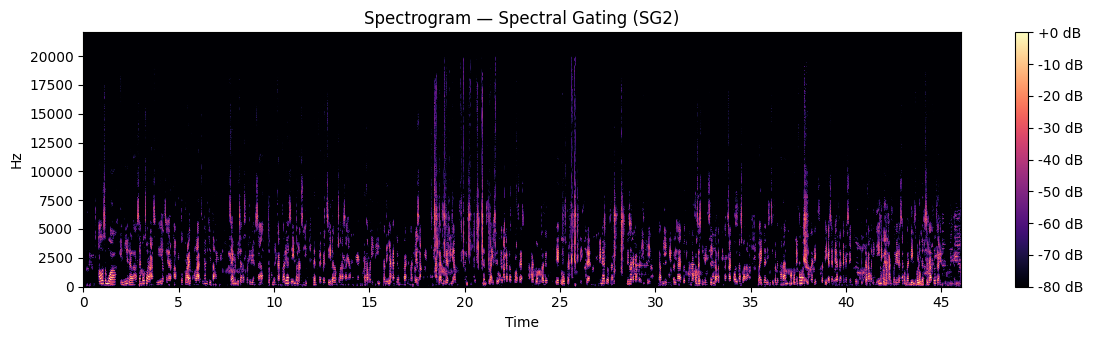

In [ ]:
plot_spec(audio_sg2, sr_common, "Spectrogram — Spectral Gating (SG2)")

## **Spectrogram — Wiener Filter Audio Noisy 1**

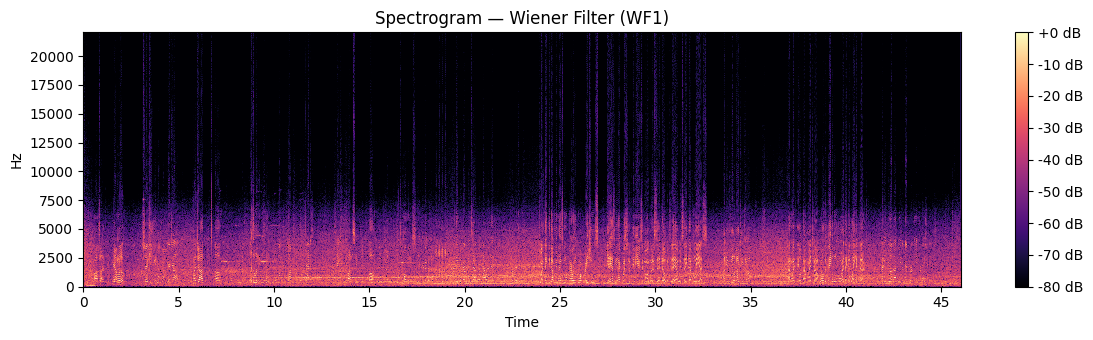

In [ ]:
plot_spec(audio_wf1, sr_common, "Spectrogram — Wiener Filter (WF1)")

## **Spectrogram — Wiener Filter Audio Noisy 2**

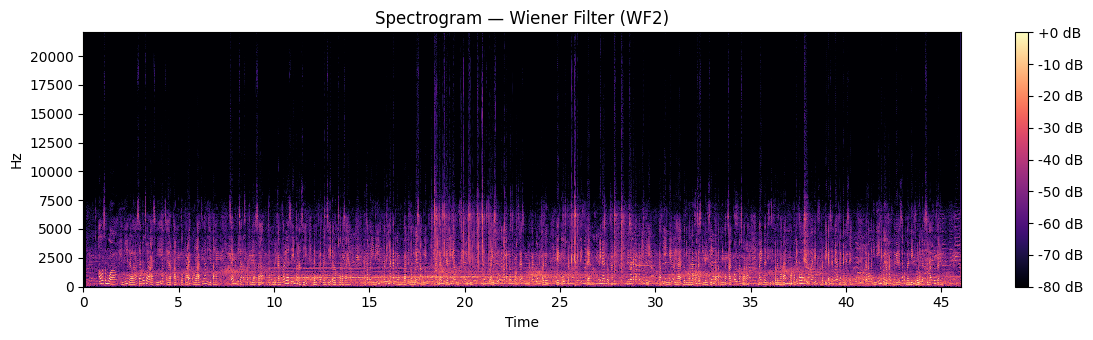

In [ ]:
plot_spec(audio_wf2, sr_common, "Spectrogram — Wiener Filter (WF2)")

In [ ]:
def plot_wave(signal, sr, title):
    t = np.linspace(0, len(signal)/sr, len(signal))
    plt.plot(t, signal)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

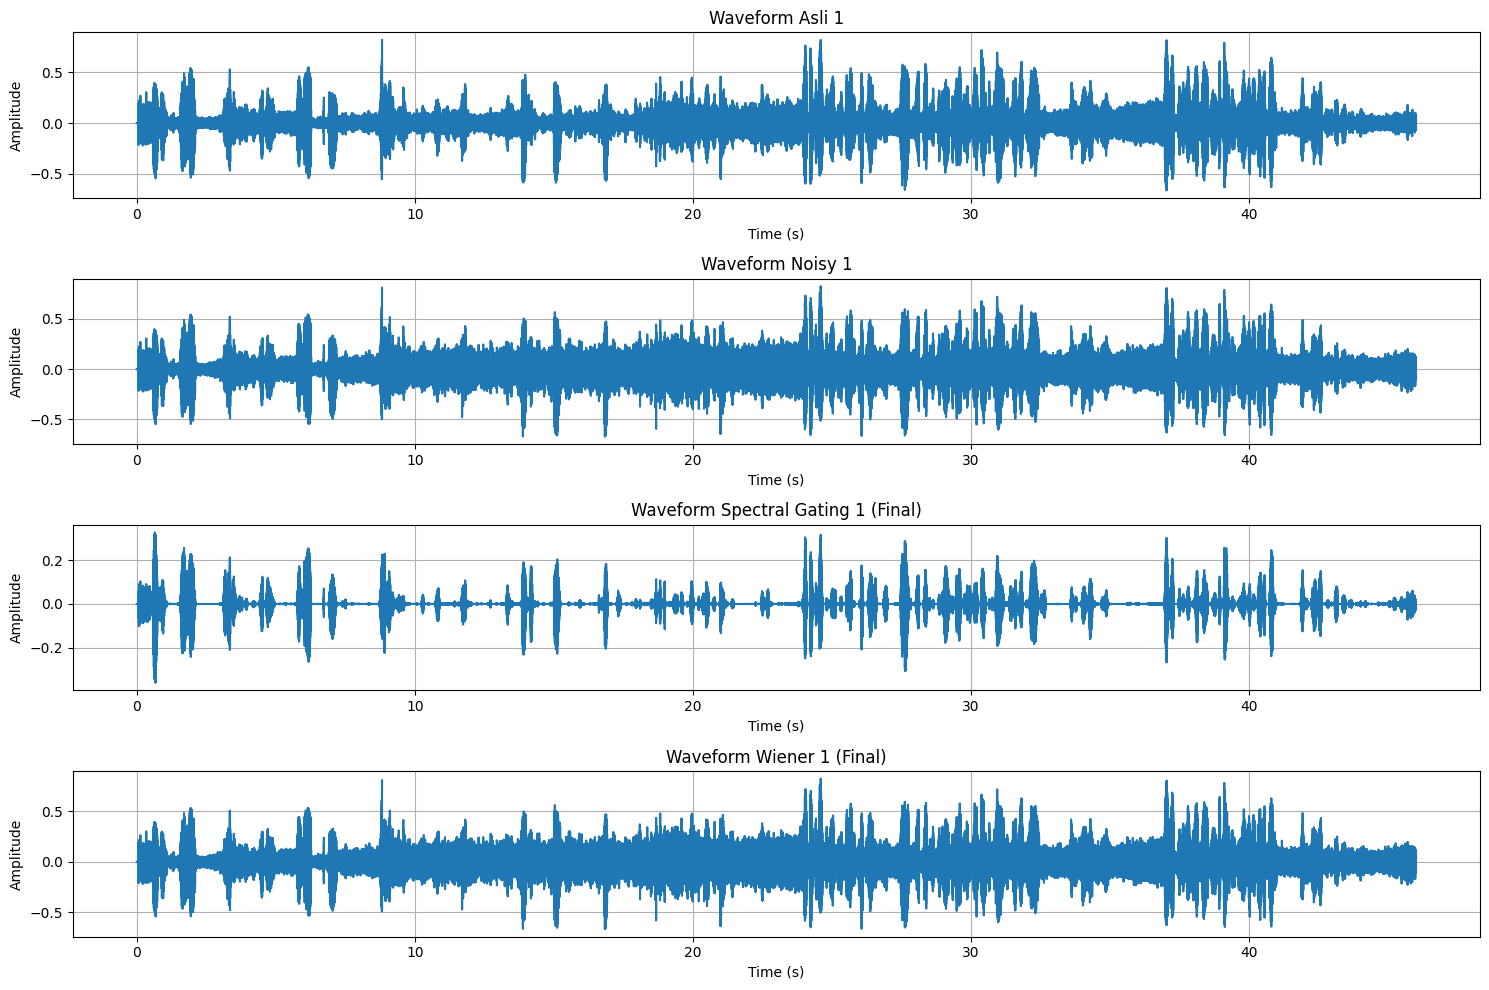

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plot_wave(audio_asli1, sr_common, "Waveform Asli 1")

plt.subplot(4,1,2)
plot_wave(audio_noisy1, sr_common, "Waveform Noisy 1")

plt.subplot(4,1,3)
plot_wave(audio_sg1, sr_common, "Waveform Spectral Gating 1 (Final)")

plt.subplot(4,1,4)
plot_wave(audio_wf1, sr_common, "Waveform Wiener 1 (Final)")

plt.tight_layout()
plt.show()

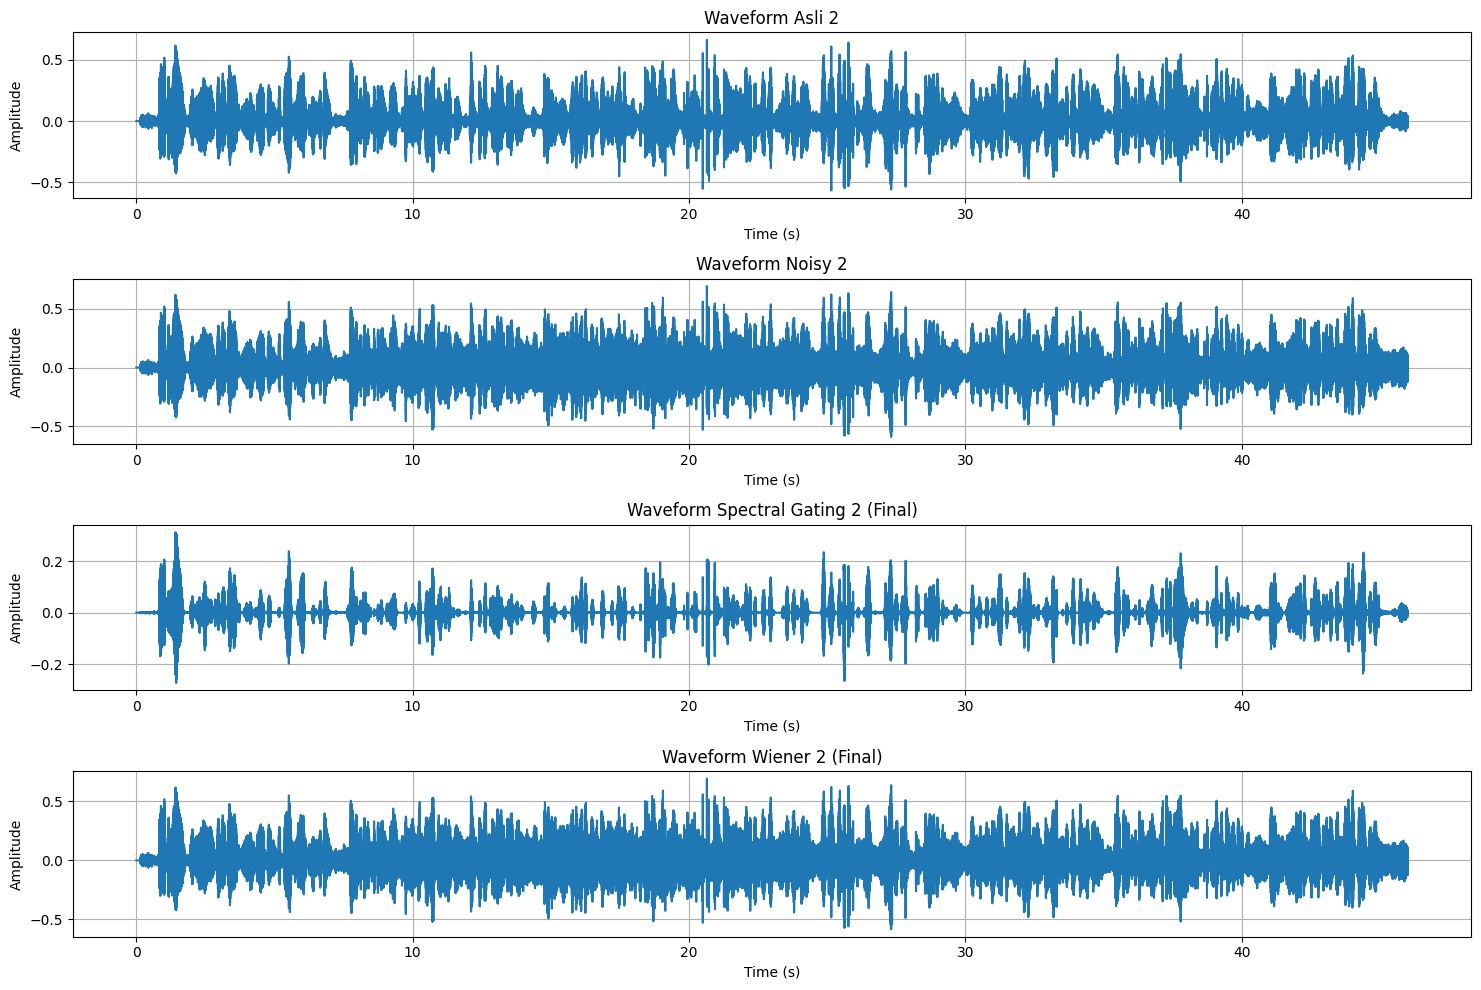

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plot_wave(audio_asli2, sr_common, "Waveform Asli 2")

plt.subplot(4,1,2)
plot_wave(audio_noisy2, sr_common, "Waveform Noisy 2")

plt.subplot(4,1,3)
plot_wave(audio_sg2, sr_common, "Waveform Spectral Gating 2 (Final)")

plt.subplot(4,1,4)
plot_wave(audio_wf2, sr_common, "Waveform Wiener 2 (Final)")

plt.tight_layout()
plt.show()

In [ ]:
def plot_spec(signal, sr, title):
    S = librosa.stft(signal)
    S_db = librosa.amplitude_to_db(abs(S))

    librosa.display.specshow(
        S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma'
    )

    plt.title(title)
    plt.colorbar(label="dB")

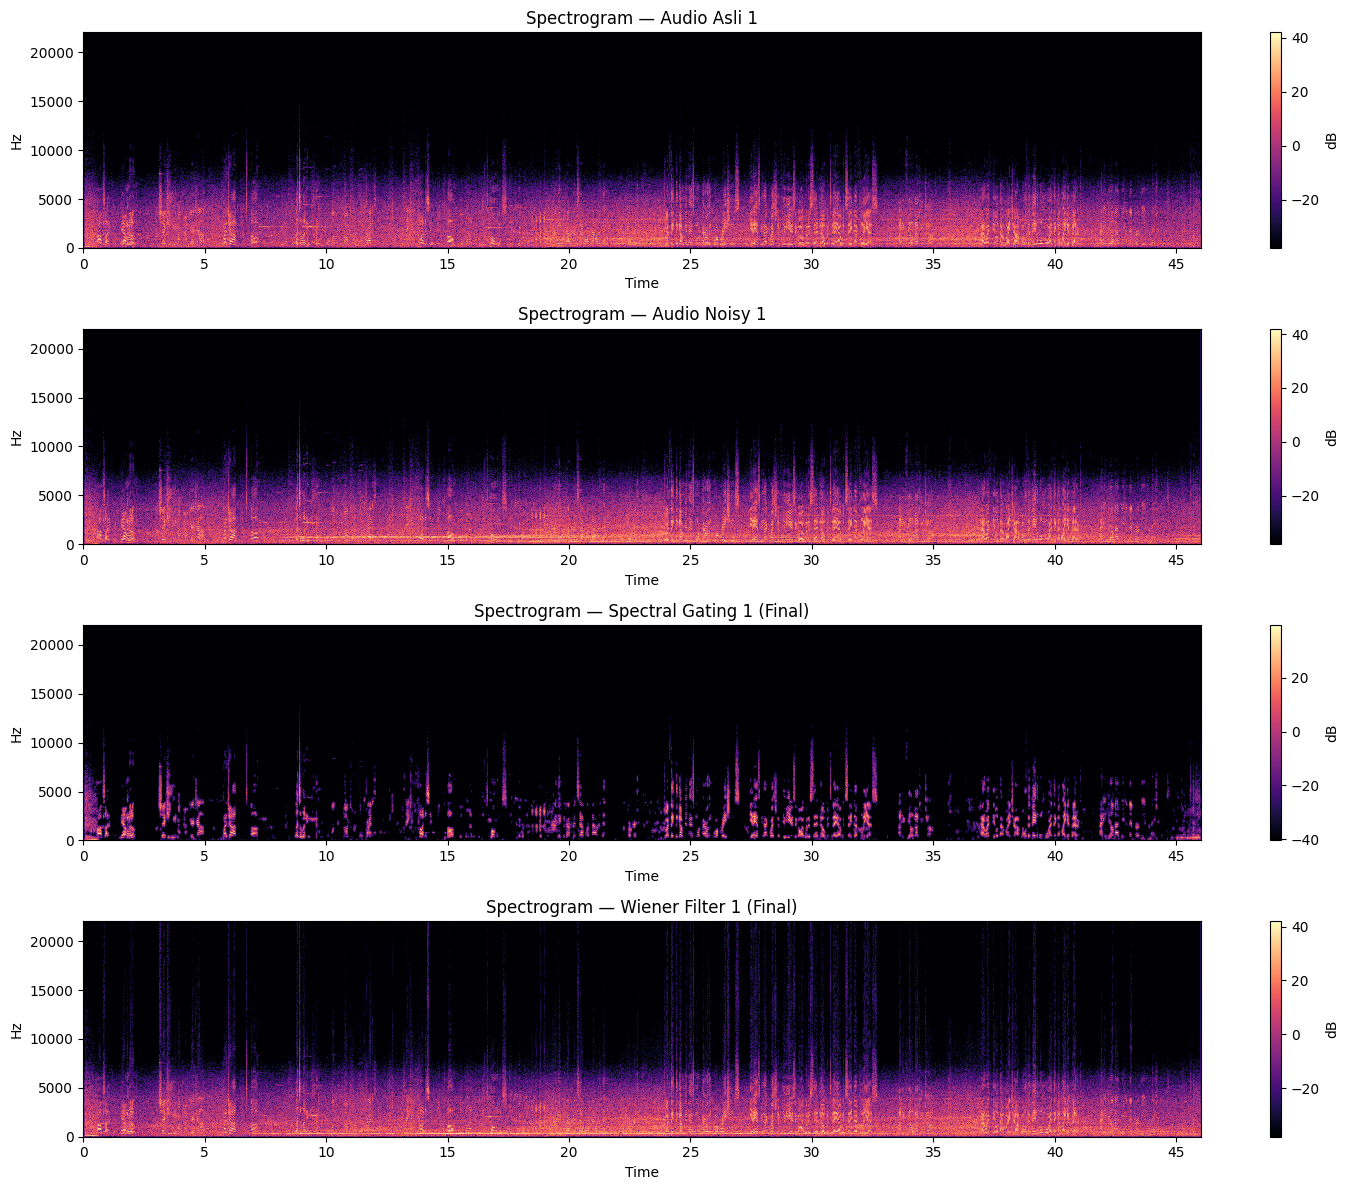

In [ ]:
plt.figure(figsize=(15,12))

plt.subplot(4,1,1)
plot_spec(audio_asli1, sr_common, "Spectrogram — Audio Asli 1")

plt.subplot(4,1,2)
plot_spec(audio_noisy1, sr_common, "Spectrogram — Audio Noisy 1")

plt.subplot(4,1,3)
plot_spec(audio_sg1, sr_common, "Spectrogram — Spectral Gating 1 (Final)")

plt.subplot(4,1,4)
plot_spec(audio_wf1, sr_common, "Spectrogram — Wiener Filter 1 (Final)")

plt.tight_layout()
plt.show()

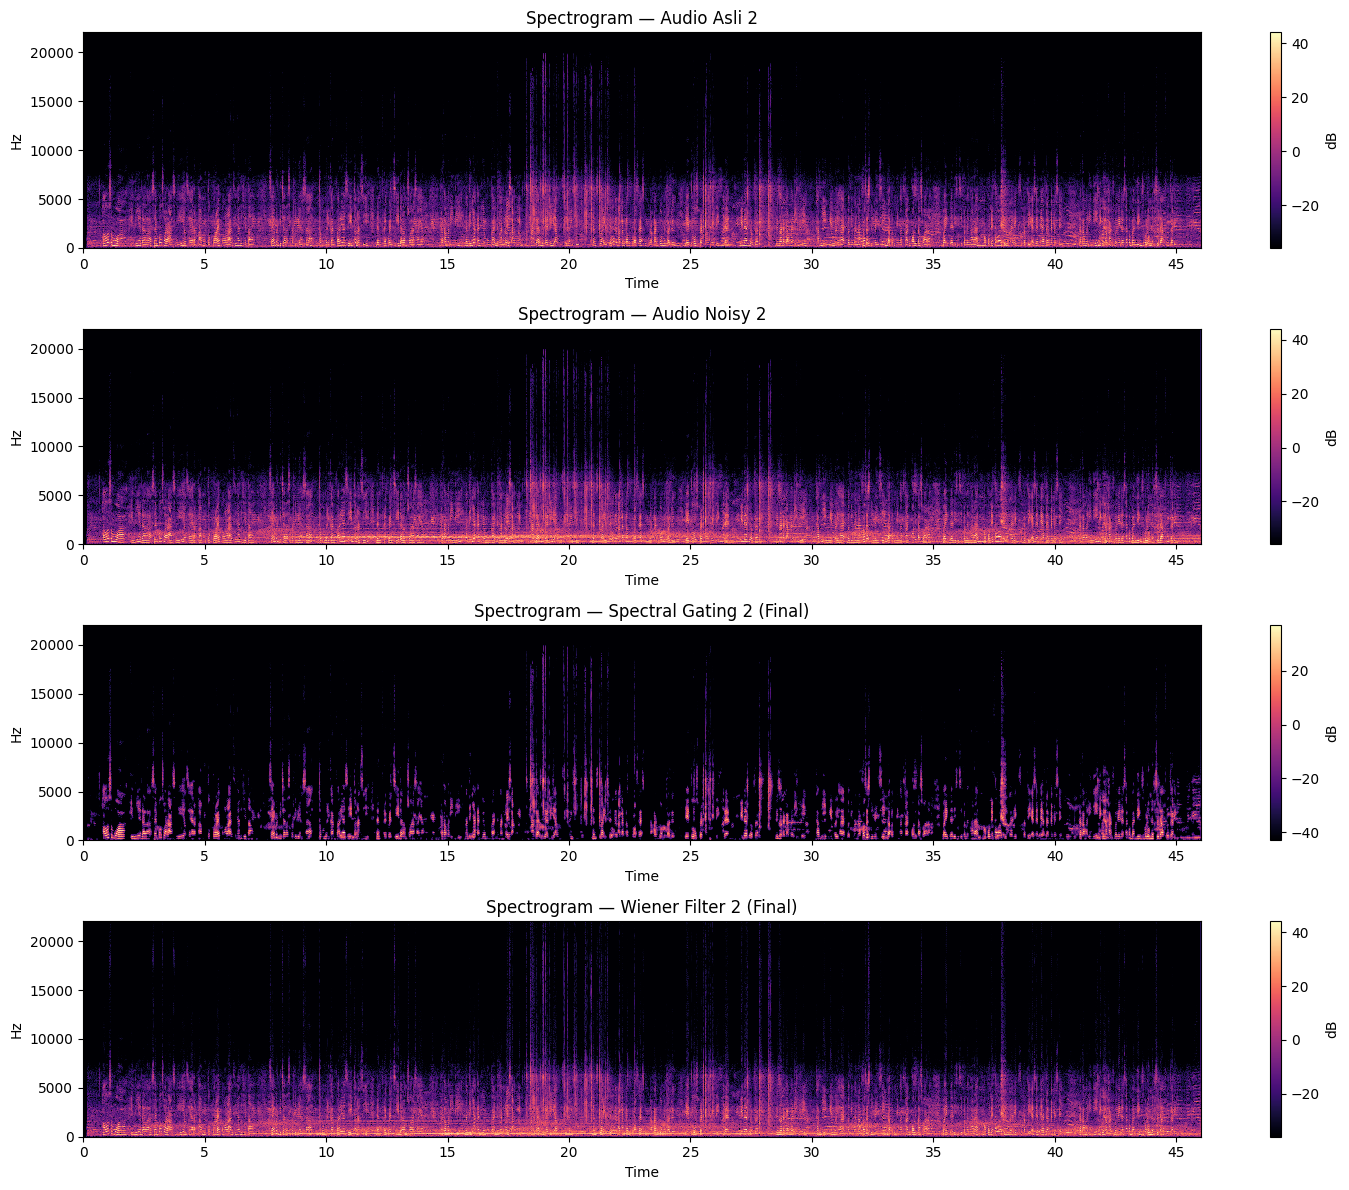

In [ ]:
plt.figure(figsize=(15,12))

plt.subplot(4,1,1)
plot_spec(audio_asli2, sr_common, "Spectrogram — Audio Asli 2")

plt.subplot(4,1,2)
plot_spec(audio_noisy2, sr_common, "Spectrogram — Audio Noisy 2")

plt.subplot(4,1,3)
plot_spec(audio_sg2, sr_common, "Spectrogram — Spectral Gating 2 (Final)")

plt.subplot(4,1,4)
plot_spec(audio_wf2, sr_common, "Spectrogram — Wiener Filter 2 (Final)")

plt.tight_layout()
plt.show()

# **Evaluasi dan Kesimpulan**

In [ ]:
sg1_eval = match_length(audio_sg1_final, audio_asli1)
sg2_eval = match_length(audio_sg2_final, audio_asli2)

wf1_eval = match_length(audio_wf1_final, audio_asli1)
wf2_eval = match_length(audio_wf2_final, audio_asli2)

snr_sg1 = snr(audio_asli1, sg1_eval)
snr_sg2 = snr(audio_asli2, sg2_eval)

snr_wf1 = snr(audio_asli1, wf1_eval)
snr_wf2 = snr(audio_asli2, wf2_eval)

mse_sg1 = mse(audio_asli1, sg1_eval)
mse_sg2 = mse(audio_asli2, sg2_eval)

mse_wf1 = mse(audio_asli1, wf1_eval)
mse_wf2 = mse(audio_asli2, wf2_eval)

def pilih_metode(snr_sg, snr_wf):
    return "Spectral Gating" if snr_sg > snr_wf else "Wiener Filter"

metode_audio1 = pilih_metode(snr_sg1, snr_wf1)
metode_audio2 = pilih_metode(snr_sg2, snr_wf2)

import pandas as pd

df_eval = pd.DataFrame({
    "Audio": ["Audio 1", "Audio 2"],
    "SNR SG": [snr_sg1, snr_sg2],
    "SNR WF": [snr_wf1, snr_wf2],
    "MSE SG": [mse_sg1, mse_sg2],
    "MSE WF": [mse_wf1, mse_wf2],
    "Metode Terbaik": [metode_audio1, metode_audio2]
})

df_eval

,Audio,SNR SG,SNR WF,MSE SG,MSE WF,Metode Terbaik
0,Audio 1,5.397269,4.113368,0.001479,0.001987,Spectral Gating
1,Audio 2,5.586927,5.131756,0.001769,0.001964,Spectral Gating


## **Simpan Tabel ke Excel**

In [ ]:
output_path = path_dir + "Evaluasi_Denoising.xlsx"
df_eval.to_excel(output_path, index=False)

print("Tabel evaluasi disimpan di:", output_path)

Tabel evaluasi disimpan di: /content/drive/Shared drives/PROYEK PSD KEL 10/Evaluasi_Denoising.xlsx
